In [2]:
import numpy as np
import pandas as pd

In [3]:
rd = pd.read_csv("R&D.csv", skiprows=4)

In [4]:
print(rd.head())
print(rd.columns)

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                    Indicator Name     Indicator Code  1960  \
0  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
1  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
2  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
3  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
4  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   

   1961  1962  1963  1964  1965  ...  2017  2018      2019  2020  2021  2022  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN       NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN       NaN   NaN   NaN   NaN   
2 

In [5]:
rd_long = rd.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="year",
    value_name="rd"
)

In [6]:
rd_long = rd_long.rename(columns={
    "Country Name": "country",
    "Country Code": "countrycode"
})

In [7]:
rd_long = rd_long[rd_long["year"].str.isnumeric()]
rd_long["year"] = rd_long["year"].astype(int)

In [8]:
rd_long = rd_long[(rd_long["year"] >= 2002) & (rd_long["year"] <= 2020)]

In [9]:
rd_long = rd_long.dropna(subset=["rd"])

In [10]:
rd_long = rd_long[rd_long["countrycode"].str.len() == 3]

regions = [
     "AFE", "AFW", "ARB", "EAS", "ECS", "LCN", "MEA",
    "NAC", "SAS", "SSF", "WLD", "CEB", "EAP", "ECA", "EUU", "EMU", 
    "LAC", "MNA", "OED", "IBD", "IBT", "IDA", "LDC", "LIC", "LMC", "LMY", "UMC",
    "MEA", "OSS", "PST", "PSS", "PRE", "SST", "SSA", "SSF", "TSA", "TSS", "TEC", 
    "TLA", "TMN", "UMC", "INX", "EAR", "EAS", "FCS", "IDB", "LIE"]

rd_long = rd_long[~rd_long["countrycode"].isin(regions)]

In [11]:
print(sorted(rd_long["country"].unique()))

['Albania', 'Algeria', 'American Samoa', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belarus', 'Belgium', 'Bermuda', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Congo, Dem. Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'East Asia & Pacific (IDA & IBRD countries)', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador', 'Estonia', 'Eswatini', 'Ethiopia', 'Faroe Islands', 'Finland', 'France', 'Gabon', 'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland', 'Guam', 'Guatemala', 'High income', 'Honduras', 'Hong Kong SAR, China', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Korea, Rep.', 'Kuwait', 'Kyrgyz Republic', 'Lao PDR', 'Late-demographic div

In [12]:
rd_long.describe()

,year
count,1846.000000
mean,2011.004875
std,5.473115
min,2002.000000
25%,2006.000000
50%,2011.000000
75%,2016.000000
max,2020.000000


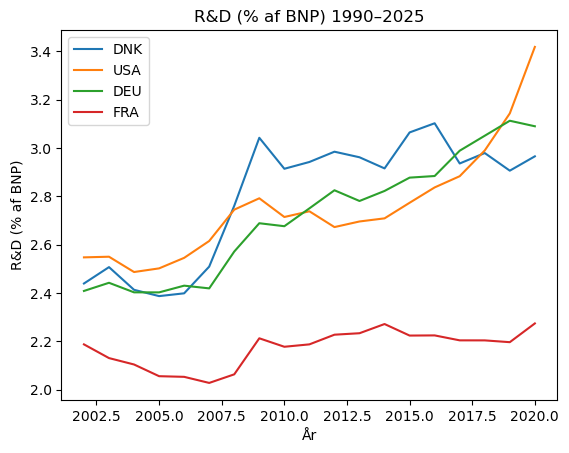

In [13]:
import matplotlib.pyplot as plt

countries = ["DNK", "USA", "DEU", "FRA"]

for c in countries:
    temp = rd_long[rd_long["countrycode"] == c].sort_values("year")
    plt.plot(temp["year"], temp["rd"], label=c)

plt.legend()
plt.title("R&D (% af BNP) 1990–2025")
plt.xlabel("År")
plt.ylabel("R&D (% af BNP)")
plt.show()

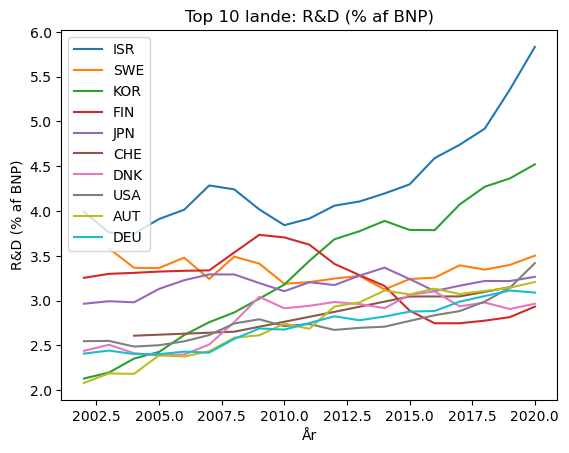

In [14]:
# Find top 10 lande med højest gennemsnitlig R&D
top_countries = (
    rd_long.groupby("countrycode")["rd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Plot
for c in top_countries:
    temp = rd_long[rd_long["countrycode"] == c].sort_values("year")
    plt.plot(temp["year"], temp["rd"], label=c)

plt.legend()
plt.title("Top 10 lande: R&D (% af BNP)")
plt.xlabel("År")
plt.ylabel("R&D (% af BNP)")
plt.show()